Dataset link: https://www.kaggle.com/datasets/rahmasleam/intel-image-dataset

In [1]:
from google.colab import files
uploaded = files.upload()

import zipfile, io, os
os.makedirs('/content/datasets', exist_ok=True)
for fn, data in uploaded.items():
    if fn.lower().endswith('.zip'):
        with zipfile.ZipFile(io.BytesIO(data), 'r') as z:
            z.extractall('/content/datasets/')
            print("Extracted", fn, "-> /content/datasets/")
    else:
        open('/content/datasets/'+fn,'wb').write(data)
        print("Saved", fn, "-> /content/datasets/")
!ls -la /content/datasets | head -n 30

Saving archive.zip to archive.zip
Extracted archive.zip -> /content/datasets/
total 12
drwxr-xr-x 3 root root 4096 Feb 26 11:18 .
drwxr-xr-x 1 root root 4096 Feb 26 11:18 ..
drwxr-xr-x 8 root root 4096 Feb 26 11:18 Intel Image Dataset


In [2]:
import os, shutil, random, glob

DATASET_ROOT = "/content/datasets"
candidates = ['seg_train', 'Intel Image Dataset', 'intel-image-classification', 'intel']
DATASET_NAME = None
for cand in candidates:
    path = os.path.join(DATASET_ROOT, cand)
    if os.path.isdir(path):
        DATASET_NAME = cand
        break
if DATASET_NAME is None:
    entries = [d for d in os.listdir(DATASET_ROOT) if os.path.isdir(os.path.join(DATASET_ROOT, d))]
    if len(entries)>0:
        DATASET_NAME = entries[0]
    else:
        raise FileNotFoundError(f"No folder found in {DATASET_ROOT}; check upload/unzip.")

SRC_PATH = os.path.join(DATASET_ROOT, DATASET_NAME)
if DATASET_NAME and os.path.isdir(os.path.join(SRC_PATH, DATASET_NAME)):
    SRC_PATH = os.path.join(SRC_PATH, DATASET_NAME)

DEST_PATH = os.path.join(DATASET_ROOT, 'intel_small')
MAX_PER_CLASS = 50

print("Source dataset folder:", SRC_PATH)
print("Destination subset folder:", DEST_PATH)
os.makedirs(DEST_PATH, exist_ok=True)

classes = sorted([d for d in os.listdir(SRC_PATH) if os.path.isdir(os.path.join(SRC_PATH, d))])
print("Detected classes:", classes)
for cls in classes:
    src_dir = os.path.join(SRC_PATH, cls)
    files = [f for f in glob.glob(os.path.join(src_dir,'*')) if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
    if len(files)==0:
        continue
    chosen = sorted(files)[:MAX_PER_CLASS]
    dst_dir = os.path.join(DEST_PATH, cls)
    os.makedirs(dst_dir, exist_ok=True)
    for f in chosen:
        shutil.copy(f, dst_dir)
print("Subset created. Contents:")
!find /content/datasets/intel_small -maxdepth 2 -type f | sed -n '1,20p'

Source dataset folder: /content/datasets/Intel Image Dataset
Destination subset folder: /content/datasets/intel_small
Detected classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Subset created. Contents:
/content/datasets/intel_small/glacier/20092.jpg
/content/datasets/intel_small/glacier/20249.jpg
/content/datasets/intel_small/glacier/20243.jpg
/content/datasets/intel_small/glacier/20352.jpg
/content/datasets/intel_small/glacier/20406.jpg
/content/datasets/intel_small/glacier/20142.jpg
/content/datasets/intel_small/glacier/20446.jpg
/content/datasets/intel_small/glacier/20195.jpg
/content/datasets/intel_small/glacier/20433.jpg
/content/datasets/intel_small/glacier/20287.jpg
/content/datasets/intel_small/glacier/20386.jpg
/content/datasets/intel_small/glacier/20187.jpg
/content/datasets/intel_small/glacier/20210.jpg
/content/datasets/intel_small/glacier/20230.jpg
/content/datasets/intel_small/glacier/20380.jpg
/content/datasets/intel_small/glacier/20457.jpg
/conte

In [3]:
# Cell 1 - imports, config and load subset
import os, glob, random, time
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

DATASET_ROOT = "/content/datasets"
DATASET_NAME = "intel_small"
DATA_PATH = os.path.join(DATASET_ROOT, DATASET_NAME)
IMG_H, IMG_W = 32, 32
MAX_PER_CLASS = 50
RANDOM_SEED = 42
TO_GRAY = True

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def load_dataset(root_path, max_per_class=50, img_size=(64,64), to_gray=True):
    classes = sorted([d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))])
    X_list, y_list = [], []
    for cls in classes:
        files = [f for f in glob.glob(os.path.join(root_path, cls, "*")) if f.lower().endswith(('.jpg','.png','.jpeg','.bmp'))]
        files = sorted(files)[:max_per_class]
        for f in files:
            try:
                img = Image.open(f)
                if to_gray:
                    img = img.convert('L')
                else:
                    img = img.convert('RGB')
                img = img.resize(img_size, Image.BILINEAR)
                arr = np.asarray(img, dtype=np.float32) / 255.0
                if to_gray:
                    X_list.append(arr)
                else:
                    X_list.append(arr.transpose(2,0,1))
                y_list.append(cls)
            except Exception as e:
                print("Error loading", f, e)
    X = np.stack(X_list, axis=0)
    y = np.array(y_list)
    return X, y, classes

print("Loading from:", DATA_PATH)
X, y, classes = load_dataset(DATA_PATH, max_per_class=MAX_PER_CLASS, img_size=(IMG_H, IMG_W), to_gray=TO_GRAY)
print("Loaded:", X.shape, "classes:", classes)

Loading from: /content/datasets/intel_small
Loaded: (300, 32, 32) classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


Classes: ['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']
X shape: (300, 32, 32) Y shape: (300, 6)
Train: (240, 32, 32) (240, 6) Test: (60, 32, 32) (60, 6)


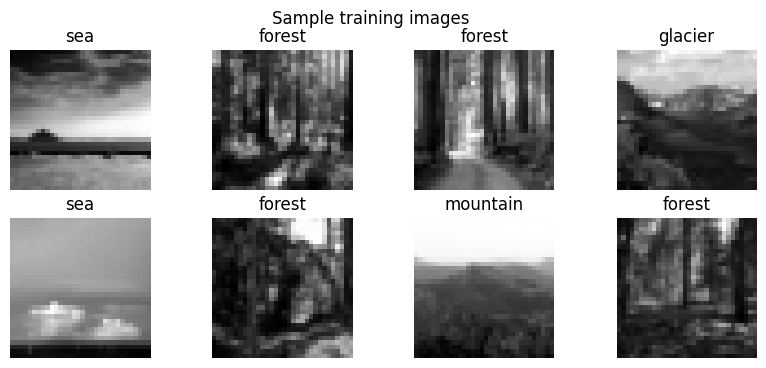

In [4]:
# Cell 2 - labels, split & visualization
assert X.shape[0] > 0

N = X.shape[0]
H, W = X.shape[1], X.shape[2]
if TO_GRAY:
    X = X.reshape(N, H, W)
else:
    X = X.reshape(N, 3, H, W)

lb = LabelBinarizer()
Y = lb.fit_transform(y)
if Y.ndim == 1:
    Y = np.vstack([1-Y, Y]).T
class_names = lb.classes_
print("Classes:", class_names)
print("X shape:", X.shape, "Y shape:", Y.shape)

X_train, X_test, Y_train, Y_test, y_train_raw, y_test_raw = train_test_split(
    X, Y, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

print("Train:", X_train.shape, Y_train.shape, "Test:", X_test.shape, Y_test.shape)

plt.figure(figsize=(10,4))
for i in range(min(8, X_train.shape[0])):
    plt.subplot(2,4,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train_raw[i])
    plt.axis('off')
plt.suptitle("Sample training images")
plt.show()

In [5]:
# Cell 3 - FullCNN implementation (NumPy)
class FullCNN:
    def __init__(self, in_h, in_w, num_classes, lr=0.01):
        self.in_h = in_h; self.in_w = in_w
        self.lr = lr
        self.F1 = 8; self.K1 = 3
        self.Wc1 = np.random.randn(self.F1, self.K1, self.K1) * np.sqrt(2.0/(self.K1*self.K1))
        self.bc1 = np.zeros((self.F1,))
        self.hc1 = in_h - self.K1 + 1
        self.wc1 = in_w - self.K1 + 1
        self.pool1_h = self.hc1 // 2
        self.pool1_w = self.wc1 // 2
        self.F2 = 12; self.K2 = 3
        self.Wc2 = np.random.randn(self.F2, self.F1, self.K2, self.K2) * np.sqrt(2.0/(self.K2*self.K2*self.F1))
        self.bc2 = np.zeros((self.F2,))
        self.hc2 = self.pool1_h - self.K2 + 1
        self.wc2 = self.pool1_w - self.K2 + 1
        self.pool2_h = self.hc2 // 2
        self.pool2_w = self.wc2 // 2
        self.flat_size = self.F2 * self.pool2_h * self.pool2_w
        self.hidden = 64
        self.W1 = np.random.randn(self.flat_size, self.hidden) * 0.01
        self.b1 = np.zeros((self.hidden,))
        self.W2 = np.random.randn(self.hidden, num_classes) * 0.01
        self.b2 = np.zeros((num_classes,))
        self.cache = {}

    def conv1_forward(self, X):
        N, H, W = X.shape
        K = self.K1; F = self.F1
        out_h = H - K + 1; out_w = W - K + 1
        out = np.zeros((N, F, out_h, out_w), dtype=np.float32)
        for n in range(N):
            for f in range(F):
                for i in range(out_h):
                    for j in range(out_w):
                        patch = X[n, i:i+K, j:j+K]
                        out[n,f,i,j] = np.sum(patch * self.Wc1[f]) + self.bc1[f]
        self.cache['conv1_in'] = X
        return out

    def conv2_forward(self, A1):
        N, F1, H1, W1 = A1.shape
        K = self.K2; F2 = self.F2
        out_h = H1 - K + 1; out_w = W1 - K + 1
        out = np.zeros((N, F2, out_h, out_w), dtype=np.float32)
        for n in range(N):
            for f2 in range(F2):
                for i in range(out_h):
                    for j in range(out_w):
                        s = 0.0
                        for f1 in range(F1):
                            patch = A1[n, f1, i:i+K, j:j+K]
                            s += np.sum(patch * self.Wc2[f2, f1])
                        out[n,f2,i,j] = s + self.bc2[f2]
        self.cache['conv2_in'] = A1
        return out

    def relu(self, Z):
        return np.maximum(0, Z)

    def maxpool2_forward(self, A, layer_name):
        N, F, H, W = A.shape
        ph = pw = 2
        out_h = H // ph; out_w = W // pw
        out = np.zeros((N, F, out_h, out_w), dtype=np.float32)
        max_idx = {}
        for n in range(N):
            for f in range(F):
                for i in range(out_h):
                    for j in range(out_w):
                        h0, w0 = i*ph, j*pw
                        patch = A[n,f,h0:h0+ph, w0:w0+pw]
                        idx = np.unravel_index(np.argmax(patch), patch.shape)
                        out[n,f,i,j] = patch[idx]
                        max_idx[(layer_name,n,f,i,j)] = (h0+idx[0], w0+idx[1])
        self.cache[f'max_idx_{layer_name}'] = max_idx
        return out

    def flatten(self, P):
        return P.reshape(P.shape[0], -1)

    def fc_forward(self, Xflat):
        Z1 = Xflat.dot(self.W1) + self.b1
        A1 = np.maximum(0, Z1)
        Z2 = A1.dot(self.W2) + self.b2
        self.cache['Xflat'] = Xflat
        self.cache['Z1'] = Z1
        self.cache['A1'] = A1
        return Z2

    def softmax(self, logits):
        ex = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        return ex / np.sum(ex, axis=1, keepdims=True)

    def forward(self, X):
        C1 = self.conv1_forward(X)
        R1 = self.relu(C1)
        P1 = self.maxpool2_forward(R1, 'p1')
        C2 = self.conv2_forward(P1)
        R2 = self.relu(C2)
        P2 = self.maxpool2_forward(R2, 'p2')
        Xf = self.flatten(P2)
        logits = self.fc_forward(Xf)
        probs = self.softmax(logits)
        self.cache['C1']=C1; self.cache['R1']=R1; self.cache['P1']=P1
        self.cache['C2']=C2; self.cache['R2']=R2; self.cache['P2']=P2
        self.cache['logits']=logits; self.cache['probs']=probs
        return probs

    def compute_loss(self, probs, Y):
        N = probs.shape[0]; eps = 1e-9
        return -np.sum(Y * np.log(probs + eps)) / N

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

    def backward(self, Y):
        N = Y.shape[0]
        probs = self.cache['probs']
        Xflat = self.cache['Xflat']
        A1 = self.cache['A1']
        P2 = self.cache['P2']
        R2 = self.cache['R2']
        P1 = self.cache['P1']
        R1 = self.cache['R1']
        conv1_in = self.cache['conv1_in']
        conv2_in = self.cache['conv2_in']

        dZ2 = (probs - Y) / N
        dW2 = A1.T.dot(dZ2)
        db2 = np.sum(dZ2, axis=0)
        dA1 = dZ2.dot(self.W2.T)
        dZ1 = dA1 * (self.cache['Z1'] > 0)
        dW1 = Xflat.T.dot(dZ1)
        db1 = np.sum(dZ1, axis=0)
        dXflat = dZ1.dot(self.W1.T)
        dP2 = dXflat.reshape(P2.shape)

        dR2 = np.zeros_like(R2)
        max_idx_p2 = self.cache['max_idx_p2']
        for (key,n,f,i,j), (hi,wj) in max_idx_p2.items():
            dR2[n,f,hi,wj] += dP2[n,f,i,j]
        dC2 = dR2 * (R2 > 0)

        dWc2 = np.zeros_like(self.Wc2)
        dbc2 = np.zeros_like(self.bc2)
        dP1 = np.zeros_like(P1)
        Np, F2p, h2, w2 = dC2.shape
        for n in range(Np):
            for f2 in range(F2p):
                for i in range(h2):
                    for j in range(w2):
                        for f1 in range(self.F1):
                            patch = P1[n, f1, i:i+self.K2, j:j+self.K2]
                            dWc2[f2,f1] += dC2[n,f2,i,j] * patch
                            dP1[n, f1, i:i+self.K2, j:j+self.K2] += dC2[n,f2,i,j] * self.Wc2[f2,f1]
                        dbc2[f2] += dC2[n,f2,i,j]

        dR1 = np.zeros_like(R1)
        max_idx_p1 = self.cache['max_idx_p1']
        for (key,n,f,i,j), (hi,wj) in max_idx_p1.items():
            dR1[n,f,hi,wj] += dP1[n,f,i,j]
        dC1 = dR1 * (R1 > 0)

        dWc1 = np.zeros_like(self.Wc1)
        dbc1 = np.zeros_like(self.bc1)
        dX = np.zeros_like(conv1_in)
        Np, F1p, h1, w1 = dC1.shape
        for n in range(Np):
            for f1 in range(F1p):
                for i in range(h1):
                    for j in range(w1):
                        patch = conv1_in[n, i:i+self.K1, j:j+self.K1]
                        dWc1[f1] += dC1[n,f1,i,j] * patch
                        dbc1[f1] += dC1[n,f1,i,j]
                        dX[n, i:i+self.K1, j:j+self.K1] += dC1[n,f1,i,j] * self.Wc1[f1]

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.Wc2 -= self.lr * dWc2
        self.bc2 -= self.lr * dbc2
        self.Wc1 -= self.lr * dWc1
        self.bc1 -= self.lr * dbc1

        return {'dW2':dW2, 'dW1':dW1, 'dWc2':dWc2, 'dWc1':dWc1}

In [6]:
import time
from tqdm.notebook import tqdm, trange

train_loss_history = []
train_acc_history  = []
val_loss_history   = []
val_acc_history    = []

def batch_generator(X, Y, batch_size=8, shuffle=True):
    idx = np.arange(X.shape[0])
    if shuffle:
        np.random.shuffle(idx)
    for i in range(0, len(idx), batch_size):
        batch_idx = idx[i:i+batch_size]
        yield X[batch_idx], Y[batch_idx]

In [7]:
# Cell 4 - Training loop
num_classes = Y_train.shape[1]
model = FullCNN(in_h=IMG_H, in_w=IMG_W, num_classes=num_classes, lr=0.01)

epochs = 12
batch_size = 8
num_batches = int(np.ceil(X_train.shape[0] / batch_size))

for epoch in range(1, epochs+1):
    t_start = time.time()
    batch_losses = []
    batch_accs = []
    pb = tqdm(total=num_batches, desc=f"Epoch {epoch}/{epochs}", leave=False)
    for xb, yb in batch_generator(X_train, Y_train, batch_size=batch_size, shuffle=True):
        probs = model.forward(xb)
        loss = model.compute_loss(probs, yb)
        preds = np.argmax(probs, axis=1)
        acc = np.mean(preds == np.argmax(yb, axis=1))

        batch_losses.append(loss)
        batch_accs.append(acc)
        model.backward(yb)
        pb.update(1)
    pb.close()

    train_loss = float(np.mean(batch_losses))
    train_acc  = float(np.mean(batch_accs))

    probs_val = model.forward(X_test)
    val_loss = float(model.compute_loss(probs_val, Y_test))
    val_preds = np.argmax(probs_val, axis=1)
    val_acc = float(np.mean(val_preds == np.argmax(Y_test, axis=1)))

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    t_epoch = time.time() - t_start
    print(f"Epoch {epoch}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc*100:.2f}% | val_loss={val_loss:.4f} val_acc={val_acc*100:.2f}% | time={t_epoch:.1f}s")

Epoch 1/12:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/12 | train_loss=1.7922 train_acc=11.25% | val_loss=1.7915 val_acc=16.67% | time=79.9s


Epoch 2/12:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 2/12 | train_loss=1.7919 train_acc=13.33% | val_loss=1.7913 val_acc=15.00% | time=80.3s


Epoch 3/12:   0%|          | 0/30 [00:00<?, ?it/s]

...

Epoch 10/12 | train_loss=1.7879 train_acc=22.08% | val_loss=1.7892 val_acc=18.33% | time=79.8s


Epoch 11/12:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 11/12 | train_loss=1.7871 train_acc=25.00% | val_loss=1.7888 val_acc=20.00% | time=80.0s


Epoch 12/12:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 12/12 | train_loss=1.7861 train_acc=21.67% | val_loss=1.7884 val_acc=16.67% | time=79.7s


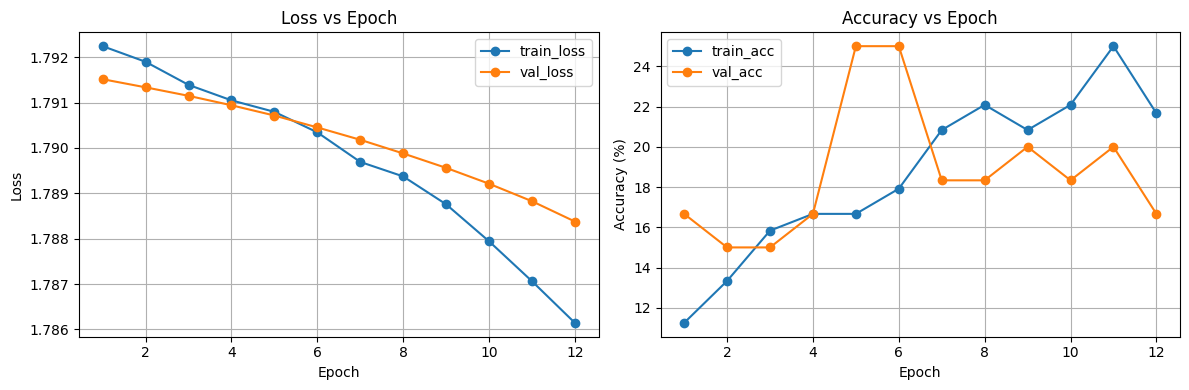

In [8]:
import matplotlib.pyplot as plt
epochs_range = np.arange(1, len(train_loss_history)+1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, train_loss_history, '-o', label='train_loss')
plt.plot(epochs_range, val_loss_history, '-o', label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss vs Epoch')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs_range, np.array(train_acc_history)*100, '-o', label='train_acc')
plt.plot(epochs_range, np.array(val_acc_history)*100, '-o', label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('Accuracy vs Epoch')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

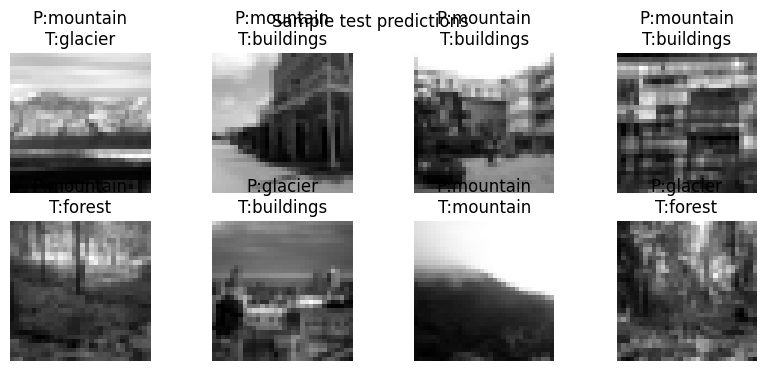

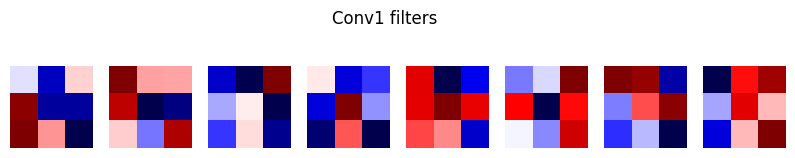

In [9]:
probs = model.forward(X_test)
preds = np.argmax(probs, axis=1)
true = np.argmax(Y_test, axis=1)

plt.figure(figsize=(10,4))
for i in range(min(8, X_test.shape[0])):
    plt.subplot(2,4,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"P:{class_names[preds[i]]}\nT:{class_names[true[i]]}")
    plt.axis('off')
plt.suptitle("Sample test predictions")
plt.show()

# visualize conv1 filters (if present)
if hasattr(model,'Wc1'):
    F1 = model.Wc1.shape[0]
    plt.figure(figsize=(10,2))
    for f in range(F1):
        plt.subplot(1, F1, f+1)
        plt.imshow(model.Wc1[f], cmap='seismic')
        plt.axis('off')
    plt.suptitle("Conv1 filters")
    plt.show()

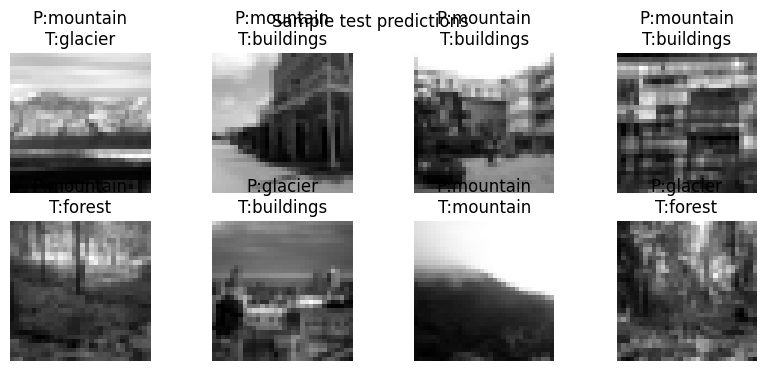

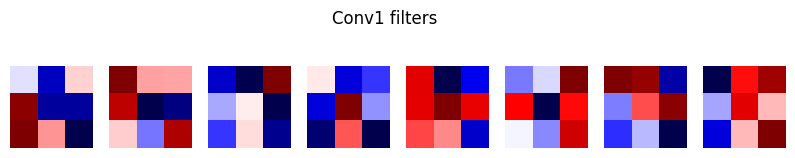

In [10]:
# Cell 5 - qualitative results
probs = model.forward(X_test)
preds = np.argmax(probs, axis=1)
true = np.argmax(Y_test, axis=1)

plt.figure(figsize=(10,4))
for i in range(min(8, X_test.shape[0])):
    plt.subplot(2,4,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"P:{class_names[preds[i]]}\nT:{class_names[true[i]]}")
    plt.axis('off')
plt.suptitle("Sample test predictions")
plt.show()

plt.figure(figsize=(10,2))
for f in range(model.F1):
    plt.subplot(1, model.F1, f+1)
    plt.imshow(model.Wc1[f], cmap='seismic')
    plt.axis('off')
plt.suptitle("Conv1 filters")
plt.show()

In [11]:
# Cell 6 - save parameters
np.savez("fullcnn_params_intel_small.npz",
         Wc1=model.Wc1, bc1=model.bc1,
         Wc2=model.Wc2, bc2=model.bc2,
         W1=model.W1, b1=model.b1,
         W2=model.W2, b2=model.b2)
print("Saved parameters to fullcnn_params_intel_small.npz")

Saved parameters to fullcnn_params_intel_small.npz
